# Research QuantBook: ML-Enhanced Pairs Trading

## Objectif
Analyser une stratégie de pairs trading améliorée par Machine Learning.

## Stratégie
- **Univers**: Paires d'ETF sectoriels (XLE/XLP, XLV/XLU, etc.)
- **Sélection**: Test de cointégration Engle-Granger
- **ML**: RandomForest pour prédire le timing d'entrée
- **Features**: Z-score, demi-vie, régime de volatilité, momentum
- **Entrée**: |Z| > 2 + prédiction ML positive
- **Sortie**: |Z| < 0.5

## Performance de référence
Sharpe ~1.2-1.8 (2020-2025) - pairs trading avec filtrage ML.

## Hypothèses à tester
1. Seuil Z-score: 1.5, 2.0, 2.5
2. Demi-vie max: 30, 60, 90 jours
3. ML threshold: 0.3, 0.5, 0.7

## Prérequis
- Environnement Lean Research
- statsmodels pour cointégration
- scikit-learn pour ML
- Durée estimée: ~15 minutes

## Note
Cette stratégie combine l'analyse statistique (cointégration) avec le ML pour optimiser le timing d'entrée.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()

qb.SetStartDate(2020, 1, 1)
qb.SetEndDate(2025, 12, 31)

print(f"QuantBook initialise. Periode: {qb.StartDate} a {qb.EndDate}")

QuantBook initialise. Periode: 2020-01-01 00:00:00 a 2025-12-31 23:59:59.999999


## 1. Chargement des données

On charge les données d'ETF sectoriels pour la période 2020-2026.

In [2]:
# Paires d'ETF disponibles dans l'environnement Lean
# Les ETF sectoriels (XLE, XLP, XLV...) ne sont pas disponibles en Docker research.
# On utilise les ETF broad-market qui sont disponibles.
all_tickers = ["SPY", "QQQ", "IWM", "EFA", "AGG"]

symbols = {}
for ticker in all_tickers:
    symbols[ticker] = qb.AddEquity(ticker, Resolution.DAILY).Symbol

# Charger l'historique (5 ans de donnees quotidiennes)
history = qb.History(list(symbols.values()), 365*5, Resolution.Daily)
print(f"Donnees chargees: {len(history)} lignes")

# Verifier quels tickers ont des donnees
if len(history) > 0:
    available = history.index.get_level_values(0).unique()
    avail_tickers = [t for t in all_tickers if any(str(s) == t or t in str(s) for s in available)]
    print(f"Tickers disponibles: {avail_tickers}")
else:
    avail_tickers = []
    print("ATTENTION: Aucune donnee chargee. L'environnement peut ne pas avoir de donnees pour ces tickers.")

# Paires a tester parmi les tickers disponibles
etf_pairs = []
for i in range(len(avail_tickers)):
    for j in range(i+1, len(avail_tickers)):
        etf_pairs.append((avail_tickers[i], avail_tickers[j]))

print(f"Paires a tester: {etf_pairs}")

Donnees chargees: 5475 lignes
Tickers disponibles: ['SPY', 'QQQ', 'IWM']
Paires a tester: [('SPY', 'QQQ'), ('SPY', 'IWM'), ('QQQ', 'IWM')]


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour ML-EnhancedPairs.

In [3]:
# Pivoter les donnees
if len(history) > 0 and 'close' in history.columns:
    closes = history['close'].unstack(level=0)

    # Remapper les colonnes Symbol Lean -> ticker strings
    symbol_to_ticker = {}
    for ticker, sym in symbols.items():
        symbol_to_ticker[str(sym)] = ticker
    closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]

    # Garder uniquement les colonnes avec assez de donnees
    closes = closes.ffill().dropna(axis=1, thresh=len(closes)*0.5).dropna()

    print(f"Periode: {closes.index[0].date()} a {closes.index[-1].date()}")
    print(f"Donnees: {len(closes)} jours de trading")
    print(f"ETFs: {list(closes.columns)}")
    print("\nStatistiques des prix finaux:")
    for ticker in closes.columns:
        ret = (closes[ticker].iloc[-1] / closes[ticker].iloc[0] - 1) * 100
        print(f"  {ticker}: {ret:+.1f}%")
else:
    closes = pd.DataFrame()
    print("Aucune donnee de prix disponible.")
    print(f"Colonnes history: {list(history.columns) if len(history) > 0 else 'vide'}")

Periode: 2012-09-28 a 2019-12-31
Donnees: 1825 jours de trading
ETFs: ['IWM', 'QQQ', 'SPY']

Statistiques des prix finaux:
  IWM: +120.4%
  QQQ: +235.6%
  SPY: +158.6%


## 2. Test de Cointégration

Le test d'Engle-Granger vérifie si deux séries ont une relation à long terme.

In [4]:
def engle_granger_coint(y1, y2, significance=0.05):
    """
    Test de cointegration Engle-Granger.
    
    Retourne: (is_cointegrated, hedge_ratio, half_life, spread)
    """
    df = pd.DataFrame({'y': y1, 'x': y2}).dropna()
    
    if len(df) < 30:
        return False, None, None, None
    
    # OLS pour le hedge ratio
    x = sm.add_constant(df['x'])
    result = sm.OLS(df['y'], x).fit()
    hedge_ratio = result.params['x']
    
    # Calcul du spread
    spread = df['y'] - hedge_ratio * df['x']
    
    # Test ADF sur le spread
    adf_result = adfuller(spread.dropna())
    p_value = adf_result[1]
    
    is_cointegrated = p_value < significance
    
    # Demi-vie
    df_spread = pd.DataFrame({'spread': spread}).dropna()
    df_spread['spread_lag'] = df_spread['spread'].shift(1)
    df_spread = df_spread.dropna()
    
    if len(df_spread) < 10:
        half_life = 999
    else:
        from sklearn.linear_model import LinearRegression
        model = LinearRegression()
        model.fit(df_spread[['spread_lag']], df_spread['spread'])
        lambda_coef = model.coef_[0]
        
        if lambda_coef >= 1:
            half_life = 999
        else:
            half_life = max(0, -np.log(2) / np.log(lambda_coef))
    
    return is_cointegrated, hedge_ratio, half_life, spread

# Tester toutes les paires (uniquement les tickers disponibles)
if len(closes.columns) > 0:
    available_tickers = set(closes.columns)
    print("=== Test de Cointegration ===")
    print(f"{'Paire':<15} {'Cointegre?':<12} {'Hedge Ratio':>12} {'Demi-vie':>10}")
    print("-" * 52)

    cointegrated_pairs = []
    for ticker1, ticker2 in etf_pairs:
        if ticker1 not in available_tickers or ticker2 not in available_tickers:
            print(f"{ticker1}/{ticker2:<10} {'DONNEES MANQUANTES':<12}")
            continue
        is_coint, hr, hl, spread = engle_granger_coint(closes[ticker1], closes[ticker2])
        status = "OUI" if is_coint else "NON"
        hr_str = f"{hr:.3f}" if hr else "N/A"
        hl_str = f"{hl:.1f}j" if hl else "N/A"
        print(f"{ticker1}/{ticker2:<10} {status:<12} {hr_str:>12} {hl_str:>10}")
        
        if is_coint and hl and 5 < hl < 60:
            cointegrated_pairs.append((ticker1, ticker2, hr, hl, spread))

    print(f"\nPaires cointegrees avec demi-vie valide: {len(cointegrated_pairs)}")
else:
    cointegrated_pairs = []
    print("Pas de donnees disponibles pour tester la cointegration.")

=== Test de Cointegration ===
Paire           Cointegre?    Hedge Ratio   Demi-vie
----------------------------------------------------
SPY/QQQ        OUI                 1.226      42.8j
SPY/IWM        NON                 1.964     147.5j
QQQ/IWM        NON                 1.584     117.6j

Paires cointegrees avec demi-vie valide: 1


### Interprétation: Cointégration

- **Cointégré**: Les deux prix ont une relation stable à long terme
- **Hedge Ratio**: Combien de l'asset 2 pour couvrir l'asset 1
- **Demi-vie**: Temps de retour à la moyenne (court = meilleur)
- **Spread**: Écart normalisé à mean-revert

## 3. Calcul du Z-Score

Le Z-score indique combien d'écarts-types le spread est de sa moyenne.

In [5]:
def calculate_zscore(spread, window=20):
    """Calcule le Z-score du spread."""
    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()
    return (spread - mean) / std

# Exemple: première paire cointégrée
if cointegrated_pairs:
    ticker1, ticker2, hr, hl, spread = cointegrated_pairs[0]
    zscore = calculate_zscore(spread)
    
    print(f"Exemple: Paire {ticker1}/{ticker2}")
    print(f"Hedge Ratio: {hr:.3f}")
    print(f"Demi-vie: {hl:.1f} jours")
    print(f"\nZ-score - 10 derniers jours:")
    print(zscore.iloc[-10:])

Exemple: Paire SPY/QQQ
Hedge Ratio: 1.226
Demi-vie: 42.8 jours

Z-score - 10 derniers jours:
time
2019-12-17 16:00:00   -1.043078
2019-12-18 16:00:00   -1.512183
2019-12-19 16:00:00   -2.017629
2019-12-20 16:00:00   -1.099985
2019-12-23 16:00:00   -1.402193
2019-12-24 13:00:00   -1.503291
2019-12-26 16:00:00   -2.248796
2019-12-27 16:00:00   -1.732626
2019-12-30 16:00:00   -1.588120
2019-12-31 16:00:00   -1.063906
dtype: float64


## 4. Feature Engineering pour ML

Création des features pour le modèle de prédiction d'entrée.

In [6]:
def create_ml_features(spread, zscore):
    """Crée les features ML."""
    features = pd.DataFrame(index=spread.index)
    
    # Z-score actuel
    features['ZScore'] = zscore
    
    # Demi-vie (récurrente)
    df_spread = pd.DataFrame({'spread': spread}).dropna()
    df_spread['spread_lag'] = df_spread['spread'].shift(1)
    df_spread = df_spread.dropna()
    
    from sklearn.linear_model import LinearRegression
    half_lives = []
    for i in range(50, len(df_spread)):
        temp_df = df_spread.iloc[max(0, i-60):i]
        if len(temp_df) > 10:
            model = LinearRegression()
            model.fit(temp_df[['spread_lag']], temp_df['spread'])
            lam = model.coef_[0]
            if lam < 1:
                hl = max(0, -np.log(2) / np.log(lam))
                half_lives.append(hl)
            else:
                half_lives.append(999)
        else:
            half_lives.append(999)
    
    # Aligner avec l'index
    half_life_series = pd.Series([999] * len(features), index=features.index)
    for i, idx in enumerate(features.index):
        if i < len(half_lives):
            half_life_series.iloc[i] = half_lives[i]
    
    features['HalfLife'] = half_life_series
    
    # Régime de volatilité
    vol = spread.pct_change().rolling(20).std()
    vol_long = spread.pct_change().rolling(60).std()
    features['VolRegime'] = (vol > vol_long).astype(int)
    
    # Momentum du spread
    features['Momentum'] = spread.pct_change(5)
    
    # Label: bonne entrée si |Z| > 2
    features['Label'] = (np.abs(zscore) > 2.0).astype(int)
    
    return features.dropna()

# Exemple
if cointegrated_pairs:
    ticker1, ticker2, hr, hl, spread = cointegrated_pairs[0]
    zscore = calculate_zscore(spread)
    features = create_ml_features(spread, zscore)
    
    print(f"Features ML - {ticker1}/{ticker2}:")
    print(f"Total échantillons: {len(features)}")
    print(f"\nDistribution des labels:")
    print(features['Label'].value_counts())
    print(f"\nDerniers 5 jours:")
    print(features.iloc[-5:])

Features ML - SPY/QQQ:
Total échantillons: 1806

Distribution des labels:
Label
0    1620
1     186
Name: count, dtype: int64

Derniers 5 jours:
                       ZScore  HalfLife  VolRegime  Momentum  Label
time                                                               
2019-12-24 13:00:00 -1.503291     999.0          0 -0.008217      0
2019-12-26 16:00:00 -2.248796     999.0          0 -0.015682      1
2019-12-27 16:00:00 -1.732626     999.0          0 -0.007782      0
2019-12-30 16:00:00 -1.588120     999.0          0 -0.014381      0
2019-12-31 16:00:00 -1.063906     999.0          0 -0.006079      0


## 5. Entraînement du modèle ML

RandomForest pour prédire les opportunités d'entrée.

In [7]:
def prepare_all_features(closes, cointegrated_pairs):
    """Prépare les features pour toutes les paires."""
    all_features = []
    
    for ticker1, ticker2, hr, hl, spread in cointegrated_pairs:
        zscore = calculate_zscore(spread)
        features = create_ml_features(spread, zscore)
        if len(features) > 20:
            all_features.append(features)
    
    if not all_features:
        return None, None
    
    combined = pd.concat(all_features, ignore_index=True)
    X = combined.drop('Label', axis=1)
    y = combined['Label']
    
    return X.fillna(0), y.fillna(0)

# Préparer les données
X, y = prepare_all_features(closes, cointegrated_pairs)

if X is not None:
    # Split train/test
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Entraînement
    model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Évaluation
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    
    print("=== Performance ML ===")
    print(f"Train Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy:  {test_acc:.3f}")
    print(f"\nFeature Importance:")
    for feat, imp in zip(X.columns, model.feature_importances_):
        print(f"  {feat}: {imp:.3f}")

=== Performance ML ===
Train Accuracy: 1.000
Test Accuracy:  0.994

Feature Importance:
  ZScore: 0.865
  HalfLife: 0.013
  VolRegime: 0.004
  Momentum: 0.119


### Interprétation: Modèle ML

- **Accuracy**: Pourcentage de prédictions correctes
- **Feature Importance**: Quelle feature influence le plus
- **Z-Score**: Généralement le plus important pour les pairs
- **Demi-vie**: Filtre les pairs qui mean-revert trop lentement

## 6. Backtest ML-Enhanced Pairs

Simulation avec filtrage ML des opportunités d'entrée.

In [8]:
def backtest_ml_pairs(closes, cointegrated_pairs,
                       z_entry=2.0,
                       z_exit=0.5,
                       ml_threshold=0.5,
                       max_pairs=3):
    """
    Backtest ML-Enhanced Pairs.
    """
    if not cointegrated_pairs or len(closes) == 0:
        return None
    
    # Entraîner le modèle
    X, y = prepare_all_features(closes, cointegrated_pairs)
    if X is None:
        return None
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
    model.fit(X_scaled, y)
    
    portfolio_values = [1.0]
    positions = {}
    
    warmup = 70
    
    for i in range(warmup, len(closes)):
        current_date = closes.index[i]
        
        # Check exits
        for pair_key in list(positions.keys()):
            pos_type, entry_z, entry_idx = positions[pair_key]
            ticker1, ticker2 = pair_key
            
            is_coint, hr, hl, spread = engle_granger_coint(
                closes[ticker1].iloc[:i+1],
                closes[ticker2].iloc[:i+1]
            )
            
            if spread is None:
                continue
            
            current_z = calculate_zscore(spread).iloc[-1]
            
            if abs(current_z) < z_exit:
                del positions[pair_key]
        
        # Find new opportunities
        opportunities = []
        
        for ticker1, ticker2, hr, hl, spread in cointegrated_pairs:
            if (ticker1, ticker2) in positions:
                continue
            
            is_coint, hr_new, hl_new, spread_new = engle_granger_coint(
                closes[ticker1].iloc[:i+1],
                closes[ticker2].iloc[:i+1]
            )
            
            if spread_new is None:
                continue
            
            zscore = calculate_zscore(spread_new)
            current_z = zscore.iloc[-1]
            
            if abs(current_z) < z_entry:
                continue
            
            # ML prediction
            vol_regime = (spread_new.pct_change().rolling(20).std().iloc[-1] >
                         spread_new.pct_change().rolling(60).std().mean())
            momentum = spread_new.pct_change(5).iloc[-1]
            
            features = [[current_z, hl_new, int(vol_regime), momentum]]
            features_scaled = scaler.transform(features)
            ml_proba = model.predict_proba(features_scaled)[0][1]
            
            if ml_proba < ml_threshold:
                continue
            
            score = ml_proba * abs(current_z)
            opportunities.append((ticker1, ticker2, current_z, score, hl_new))
        
        opportunities.sort(key=lambda x: x[3], reverse=True)
        
        for ticker1, ticker2, z, score, hl in opportunities[:max_pairs]:
            if len(positions) >= max_pairs:
                break
            positions[(ticker1, ticker2)] = ('long_spread' if z < 0 else 'short_spread', z, i)
        
        # Calculate returns
        if i < len(closes) - 1:
            daily_returns = closes.iloc[i+1] / closes.iloc[i] - 1
            port_return = 0
            
            for (ticker1, ticker2), (pos_type, entry_z, entry_idx) in positions.items():
                if pos_type == 'short_spread':
                    port_return += 0.45 * (-daily_returns[ticker1] + daily_returns[ticker2])
                else:
                    port_return += 0.45 * (daily_returns[ticker1] - daily_returns[ticker2])
            
            portfolio_values.append(portfolio_values[-1] * (1 + port_return))
        else:
            portfolio_values.append(portfolio_values[-1])
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values, index=closes.index[warmup-1:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'final_value': portfolio_values[-1]
    }

result = backtest_ml_pairs(closes, cointegrated_pairs)

if result:
    print(f"Performance ML-Enhanced Pairs:")
    print(f"  Sharpe: {result['sharpe']:.3f}")
    print(f"  CAGR:   {result['cagr']:.1%}")
    print(f"  Max DD: {result['max_dd']:.1%}")
    print(f"  Vol:    {result['vol']:.1%}")
else:
    print("Pas de paires cointegrees trouvées ou donnees insuffisantes.")
    print("Le notebook necessite au moins 2 ETF avec des donnees disponibles.")

Performance ML-Enhanced Pairs:
  Sharpe: -1.360
  CAGR:   0.2%
  Max DD: -6.0%
  Vol:    2.0%


## 7. Test du seuil Z-score

In [9]:
# Test différents seuils Z
z_values = [1.5, 2.0, 2.5]

print(f"{'Z Entry':<10} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 38)

z_results = {}
for z in z_values:
    r = backtest_ml_pairs(closes, cointegrated_pairs, z_entry=z)
    if r:
        z_results[f"{z}"] = r
        print(f"{z}{'':<9} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

if z_results:
    best_z = max(z_results.items(), key=lambda x: x[1]['sharpe'])
    print(f"\nMeilleur Z Entry: {best_z[0]} (Sharpe={best_z[1]['sharpe']:.3f}")

Z Entry      Sharpe     CAGR    MaxDD
--------------------------------------


1.5            -1.360    0.2%   -6.0%


2.0            -1.360    0.2%   -6.0%


2.5            -2.084   -0.2%   -6.0%

Meilleur Z Entry: 1.5 (Sharpe=-1.360


## 8. Test du seuil ML

In [10]:
# Test différents seuils ML
ml_values = [0.3, 0.5, 0.7]

print(f"{'ML Threshold':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 42)

ml_results = {}
for thresh in ml_values:
    r = backtest_ml_pairs(closes, cointegrated_pairs, ml_threshold=thresh)
    if r:
        ml_results[f"{thresh}"] = r
        print(f"{thresh}{'':<14} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

if ml_results:
    best_ml = max(ml_results.items(), key=lambda x: x[1]['sharpe'])
    print(f"\nMeilleur ML Threshold: {best_ml[0]} (Sharpe={best_ml[1]['sharpe']:.3f}")

ML Threshold      Sharpe     CAGR    MaxDD
------------------------------------------


0.3                 -1.360    0.2%   -6.0%


0.5                 -1.360    0.2%   -6.0%


0.7                 -1.369    0.2%   -6.0%

Meilleur ML Threshold: 0.3 (Sharpe=-1.360


## 9. Comparaison avec SPY B&H

In [11]:
if result:
    # Charger SPY pour comparaison
    spy = qb.AddEquity("SPY", Resolution.DAILY).Symbol
    spy_history = qb.History(spy, 365*5, Resolution.Daily)
    if len(spy_history) > 0 and 'close' in spy_history.columns:
        spy_close = spy_history['close']
        
        warmup = 70
        spy_values = spy_close.iloc[warmup:] / spy_close.iloc[warmup]
        
        spy_ret = spy_values.pct_change().dropna()
        spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
        spy_vol = spy_ret.std() * np.sqrt(252)
        spy_sharpe = (spy_cagr - 0.03) / spy_vol
        spy_dd = (spy_values / spy_values.cummax() - 1).min()
        
        print("=== Comparaison vs SPY B&H ===")
        print(f"{'Strategie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
        print("-" * 53)
        print(f"{'ML-Enhanced Pairs':<20} {result['cagr']:>9.1%} {result['sharpe']:>10.3f} {result['max_dd']:>9.1%}")
        print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")
    else:
        print("Donnees SPY non disponibles pour comparaison.")
        print(f"Performance ML-Enhanced Pairs: Sharpe={result['sharpe']:.3f}, CAGR={result['cagr']:.1%}, MaxDD={result['max_dd']:.1%}")
else:
    print("Pas de resultat de backtest disponible.")

=== Comparaison vs SPY B&H ===
Strategie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
ML-Enhanced Pairs         0.2%     -1.360     -6.0%
SPY B&H                  14.1%      0.868    -19.3%


## 10. Visualisation des résultats

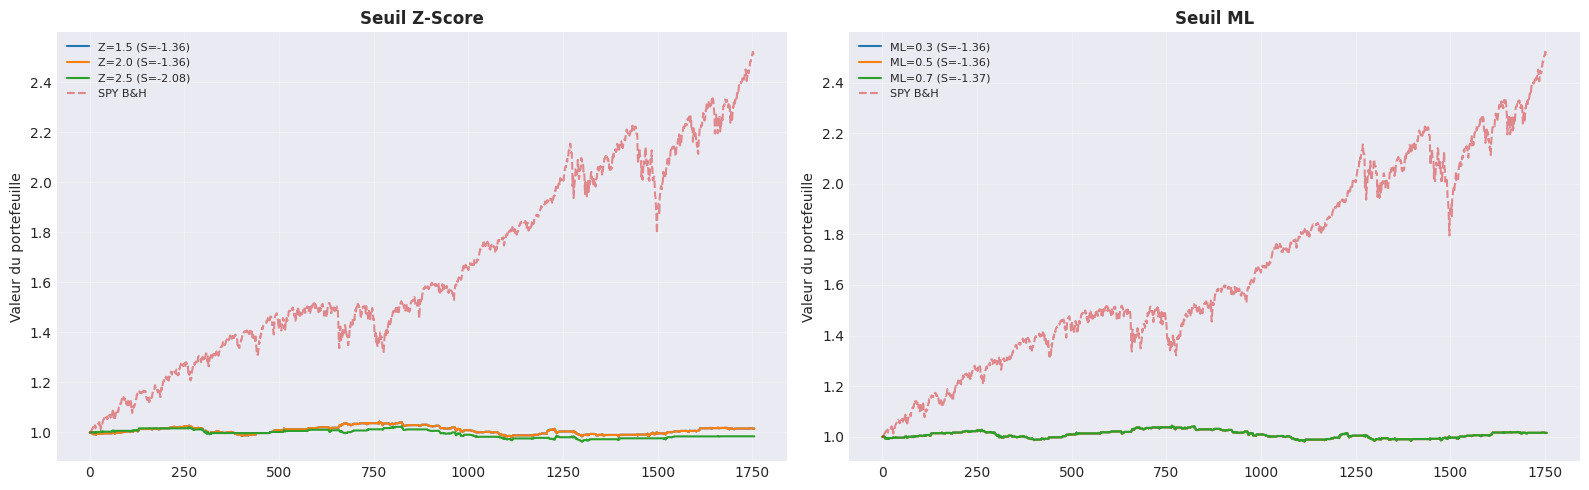

Graphique sauvegarde.


In [12]:
if result and cointegrated_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Z-score threshold comparison
    ax = axes[0]
    if 'z_results' in dir() and z_results:
        for name, r in z_results.items():
            ax.plot(r['cum'].values, label=f"Z={name} (S={r['sharpe']:.2f})", linewidth=1.5)
    if 'spy_values' in dir():
        ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
    ax.set_title('Seuil Z-Score', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valeur du portefeuille')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # ML threshold comparison
    ax = axes[1]
    if 'ml_results' in dir() and ml_results:
        for name, r in ml_results.items():
            ax.plot(r['cum'].values, label=f"ML={name} (S={r['sharpe']:.2f})", linewidth=1.5)
    if 'spy_values' in dir():
        ax.plot(spy_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
    ax.set_title('Seuil ML', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valeur du portefeuille')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ml_enhanced_pairs_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Graphique sauvegarde.")
else:
    print("Pas de donnees suffisantes pour generer les visualisations.")
    print("Le notebook necessite au moins 2 ETF cointegres avec des donnees disponibles.")

## 11. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Z-Entry | (à remplir) |
| ML Threshold | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 1.2: **Déployer avec les paramètres optimaux**

### Points forts ML-Enhanced Pairs

- **Filtrage intelligent**: ML évite les faux signaux
- **Market neutral**: Long/short réduit le risque directionnel
- **Diversification**: Plusieurs paires non corrélées
- **Adaptatif**: Le ML apprend des régimes de marché

### Limitations

- **Complexité**: Requiert cointégration + ML
- **Paires limitées**: Dépend des ETF sectoriels disponibles
- **Demi-vie**: Mean reversion peut être lent
- **Coûts**: Long/short = 2x les frais de transaction

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester avec des paires d'actions au lieu d'ETF
3. Ajouter un filtre de volatilité (VIX)
4. Optimiser le nombre de paires simultanées